In [16]:
# 导入示例代码所需库
import numpy as np
import sklearn
import sklearn.datasets
import sklearn.svm
import sklearn.linear_model
import sklearn.model_selection
import sklearn.metrics
import matplotlib.pyplot as plt

In [17]:
# 实验步骤1 实现LinearRegression类
# 要求：只允许使用numpy
class LinearRegression(object):
    def __init__(self):
        self.w = None 
        # 初始化线性回归模型
        # return super().__init__()

    def fit(self, X, y):
        # 根据数据集X与标签y计算得到线性模型参数
        # 提示： 使用解析解方法计算模型参数，参数计算可以参考课本式(3.11)
        # 提示： numpy中矩阵求逆使用可以使用np.linalg.inv
        # 提示： numpy中矩阵乘法使用@表示，如X@Y表示X和Y做矩阵乘法
        ones = np.ones((X.shape[0], 1))
        X_b = np.hstack([ones, X])
        # 计算参数：w = (X_b^T X_b)^{-1} X_b^T y
        self.w = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
        # raise NotImplementedError
        
    def predict(self, X):
        # 根据计算得到的模型参数预计X标签
        # 提示：预测过程参考课本式(3.11)与式(3.12)
        ones = np.ones((X.shape[0], 1))
        X_b = np.hstack([ones, X])
        y_pred = X_b @ self.w # type: ignore
        # raise NotImplementedError
        return y_pred

In [18]:
# 加载糖尿病数据集
# X, y = sklearn.datasets.load_diabetes(return_X_y = True)
# 实验步骤3.1 不使用sklearn，写代码加载select_diabetes.tab.txt文件中所包含数据集内容
# 修复：文件首行为表头，需跳过
def load_select_diabetes(filepath='select_diabetes.tab.txt'):
    data = np.loadtxt(filepath, delimiter='\t', skiprows=1)
    X = data[:, :-1]      # 所有行，除最后一列外为特征
    y = data[:, -1]       # 最后一列为标签
    return X, y

X, y = load_select_diabetes()

In [19]:
# 划分训练集与测试集
# X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.4)
# 实验步骤3.2 不使用sklearn，写代码加载将X, y划分为训练集（X_train, y_train）与测试集（X_test, y_test）
def train_test_split_manual(X, y, test_size=0.4, random_seed=42):

    np.random.seed(random_seed)
    n_samples = X.shape[0]
    indices = np.random.permutation(n_samples)          # 随机打乱索引
    test_num = int(n_samples * test_size)
    test_idx = indices[:test_num]
    train_idx = indices[test_num:]

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    return X_train, X_test, y_train, y_test

# 使用手动划分函数
X_train, X_test, y_train, y_test = train_test_split_manual(X, y, test_size=0.4)

In [20]:
# 定义线性回归模型
sk_regr = sklearn.linear_model.LinearRegression()
sk_regr.fit(X_train, y_train)
y_pred_sk = sk_regr.predict(X_test)
# 若使用自己写的线性回归模型，改成以下形式
my_regr = LinearRegression()
my_regr.fit(X_train, y_train)
y_pred_my = my_regr.predict(X_test)
# 实验步骤2 用自己实现的LinearRegression替换sklearn.linear_model.LinearRegression
#           并比较两者之间的性能差异

In [21]:
# # 使用训练集数据训练模型
# regr.fit(X_train, y_train)
# # 使用测试集数据进行预测
# y_pred = regr.predict(X_test)
def mean_squared_error_manual(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

mse_my = mean_squared_error_manual(y_test, y_pred_my)
mse_sk = mean_squared_error_manual(y_test, y_pred_sk)

In [22]:
# 计算预测结果的均方误差# 实验步骤3.3 不使用sklearn，写代码计算预测均方误差
print("=== 性能对比 ===")
print(f"自己实现的LinearRegression MSE: {mse_my:.2f}")
print(f"sklearn LinearRegression MSE:     {mse_sk:.2f}")
print(f"两者MSE差值: {abs(mse_my - mse_sk):.6f}")


=== 性能对比 ===
自己实现的LinearRegression MSE: 2849.67
sklearn LinearRegression MSE:     2849.67
两者MSE差值: 0.000000


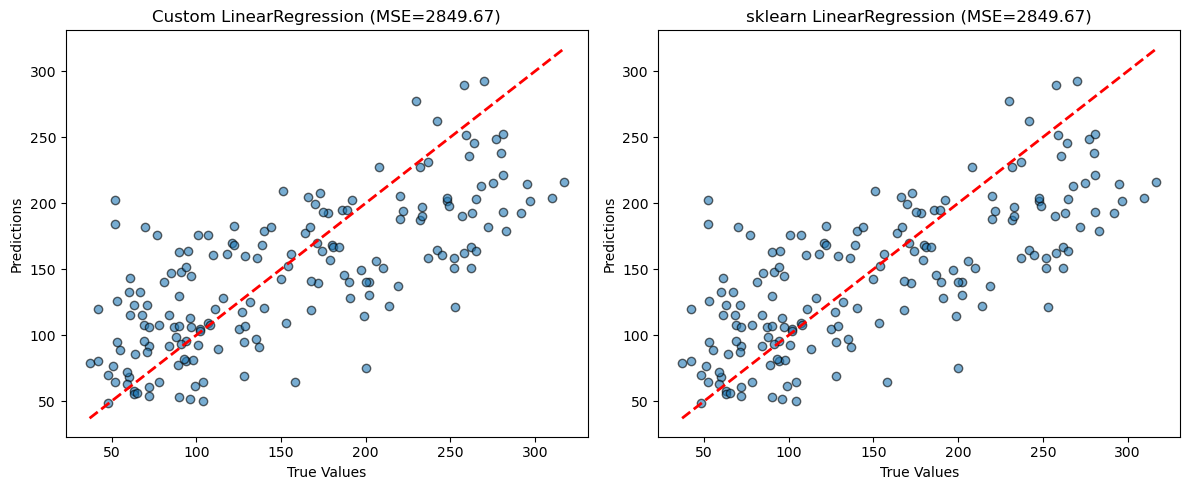

In [23]:
# 画出预测值与实际值之间的分布
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_my, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title(f"Custom LinearRegression (MSE={mse_my:.2f})")

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_sk, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title(f"sklearn LinearRegression (MSE={mse_sk:.2f})")

plt.tight_layout()
plt.show()